In [1]:

#
# Goal: translate the cleaned customer-level data into business metrics
# that a CFO/CRO/Head of Customer Success would actually track.
#
# IMPORTANT CAVEAT: this dataset is a single snapshot (one row = one
# customer's current state), not a time series. There is no date/month
# column. Metrics below are therefore computed as "current snapshot"
# values (MRR/ARR/ARPU as of now), not as a trend over time. In a real
# production environment, these would be recomputed monthly and tracked
# over time — that trending logic belongs in the Power BI layer (Step 8),
# fed by repeated snapshots, not simulated here from a single file.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

train = pd.read_csv("../data/processed/train_clean.csv")
train.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,ContentType,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,Both,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Movies,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Movies,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,TV Shows,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,TV Shows,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,0


In [2]:
def compute_mrr(df: pd.DataFrame, revenue_col: str = "MonthlyCharges", churn_col: str = "Churn") -> float:
    """
    Monthly Recurring Revenue = sum of monthly charges from currently
    ACTIVE (non-churned) customers only. Churned customers no longer
    contribute recurring revenue, so they are excluded by definition.
    """
    return df.loc[df[churn_col] == 0, revenue_col].sum()


def compute_arr(mrr: float) -> float:
    """Annual Recurring Revenue = MRR x 12 (standard SaaS annualization)."""
    return mrr * 12


def compute_arpu(df: pd.DataFrame, revenue_col: str = "MonthlyCharges", churn_col: str = "Churn") -> float:
    """
    Average Revenue Per User = average monthly charge among active customers.
    Measures monetization efficiency independent of total customer count.
    """
    active = df[df[churn_col] == 0]
    return active[revenue_col].mean()


mrr = compute_mrr(train)
arr = compute_arr(mrr)
arpu = compute_arpu(train)

print(f"MRR  : ${mrr:,.2f}")
print(f"ARR  : ${arr:,.2f}")
print(f"ARPU : ${arpu:,.2f} / active customer / month")

MRR  : $2,452,372.70
ARR  : $29,428,472.36
ARPU : $12.29 / active customer / month


In [3]:
def compute_churn_rate(df: pd.DataFrame, churn_col: str = "Churn") -> float:
    """Churn Rate (%) = proportion of customers who churned."""
    return df[churn_col].mean() * 100


def compute_revenue_lost_from_churn(df: pd.DataFrame, revenue_col: str = "MonthlyCharges", churn_col: str = "Churn") -> float:
    """
    Revenue Lost from Churn = monthly revenue that disappeared because
    these customers left. This is the direct $ impact of churn, and the
    number that justifies investment in retention initiatives.
    """
    return df.loc[df[churn_col] == 1, revenue_col].sum()


churn_rate = compute_churn_rate(train)
revenue_lost = compute_revenue_lost_from_churn(train)

# Revenue lost as a % of what MRR WOULD have been without churn —
# frames the loss in relative, not just absolute, terms.
potential_mrr = mrr + revenue_lost
revenue_lost_pct = (revenue_lost / potential_mrr) * 100

print(f"Churn Rate               : {churn_rate:.2f}%")
print(f"Revenue Lost from Churn  : ${revenue_lost:,.2f} / month")
print(f"Revenue Lost as % of potential MRR: {revenue_lost_pct:.2f}%")

Churn Rate               : 18.12%
Revenue Lost from Churn  : $592,696.24 / month
Revenue Lost as % of potential MRR: 19.46%


In [4]:
def compute_clv(arpu: float, churn_rate_pct: float, gross_margin: float = 0.80) -> float:
    """
    CLV = (ARPU x Gross Margin) / Monthly Churn Rate

    Standard SaaS formula: assumes the churn rate observed here behaves
    as a monthly churn rate (reasonable given the account-age distribution
    in this dataset). Gross margin of 80% is a common industry default
    for subscription/media services (adjust if a real margin figure is
    available) — reflects that not 100% of revenue is profit
    (content licensing, infrastructure, support costs).
    """
    monthly_churn = churn_rate_pct / 100
    if monthly_churn == 0:
        return None
    return (arpu * gross_margin) / monthly_churn


clv = compute_clv(arpu, churn_rate)
print(f"CLV (at 80% gross margin): ${clv:,.2f} per customer, lifetime value")

# Sensitivity check: CLV is highly sensitive to the margin assumption.
# Showing a small range instead of a single point estimate is more
# defensible in a business presentation than a single "exact" number.
for margin in [0.6, 0.7, 0.8, 0.9]:
    print(f"  Margin {margin:.0%}: CLV = ${compute_clv(arpu, churn_rate, margin):,.2f}")

CLV (at 80% gross margin): $54.23 per customer, lifetime value
  Margin 60%: CLV = $40.68
  Margin 70%: CLV = $47.45
  Margin 80%: CLV = $54.23
  Margin 90%: CLV = $61.01


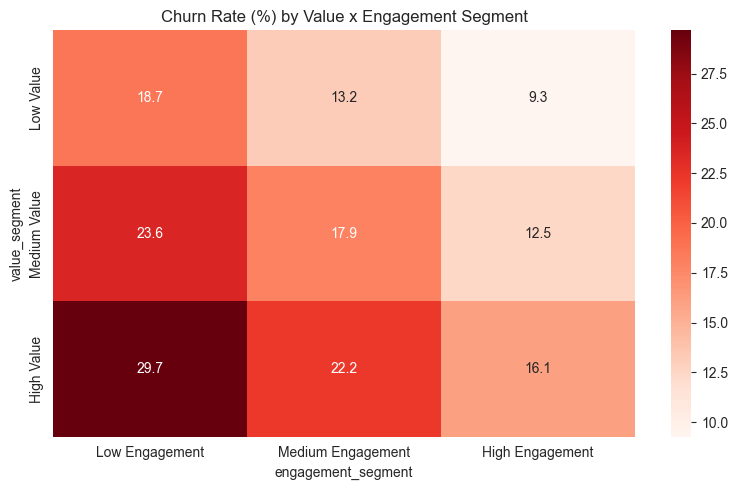

In [5]:
def segment_customers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Two independent segmentations, combined into a 2D matrix:
    - Value segment: based on MonthlyCharges (revenue tercile).
    - Engagement segment: based on ViewingHoursPerWeek (usage tercile),
      the strongest engagement signal found in the EDA.

    qcut (quantile-based) is used instead of fixed thresholds so the
    segmentation adapts automatically if the underlying data changes,
    rather than relying on arbitrary hardcoded cutoffs.
    """
    df = df.copy()

    df["value_segment"] = pd.qcut(
        df["MonthlyCharges"], q=3, labels=["Low Value", "Medium Value", "High Value"]
    )
    df["engagement_segment"] = pd.qcut(
        df["ViewingHoursPerWeek"].rank(method="first"), q=3,
        labels=["Low Engagement", "Medium Engagement", "High Engagement"]
    )

    return df


train_segmented = segment_customers(train)

# Churn rate per segment combination — the actionable output for
# Customer Success: which segment combinations are highest risk?
segment_churn = (
    train_segmented.groupby(["value_segment", "engagement_segment"], observed=True)["Churn"]
    .mean()
    .unstack() * 100
)

plt.figure(figsize=(8, 5))
sns.heatmap(segment_churn, annot=True, fmt=".1f", cmap="Reds")
plt.title("Churn Rate (%) by Value x Engagement Segment")
plt.tight_layout()
plt.savefig("../reports/figures/churn_by_value_engagement_segment.png", dpi=150)
plt.show()

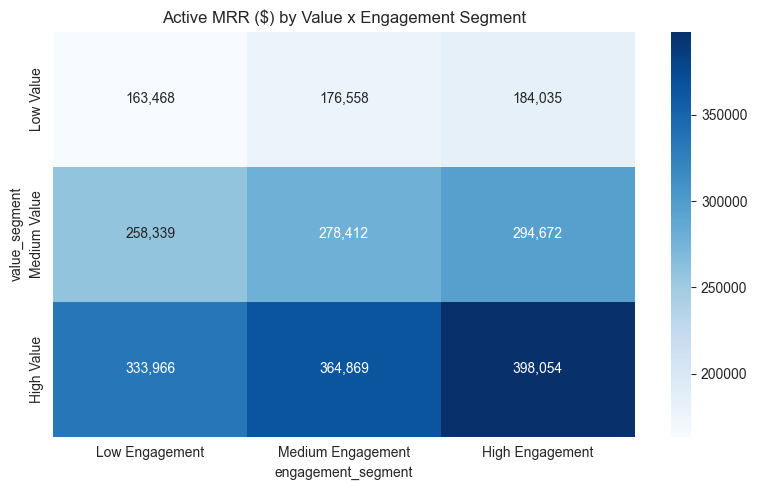

In [6]:
# Revenue exposure per segment — not just churn rate, but the $ at stake.
# A segment can have a moderate churn rate but represent the majority of
# revenue at risk, which changes prioritization for retention spend.
segment_revenue_exposure = (
    train_segmented[train_segmented["Churn"] == 0]
    .groupby(["value_segment", "engagement_segment"], observed=True)["MonthlyCharges"]
    .sum()
    .unstack()
)

plt.figure(figsize=(8, 5))
sns.heatmap(segment_revenue_exposure, annot=True, fmt=",.0f", cmap="Blues")
plt.title("Active MRR ($) by Value x Engagement Segment")
plt.tight_layout()
plt.savefig("../reports/figures/mrr_by_value_engagement_segment.png", dpi=150)
plt.show()

                  n_customers  churn_rate_pct  avg_monthly_charge  total_mrr
SubscriptionType                                                            
Basic                   81050           19.65               12.50  799652.07
Standard                81920           18.43               12.49  820413.76
Premium                 80817           16.28               12.48  832306.87


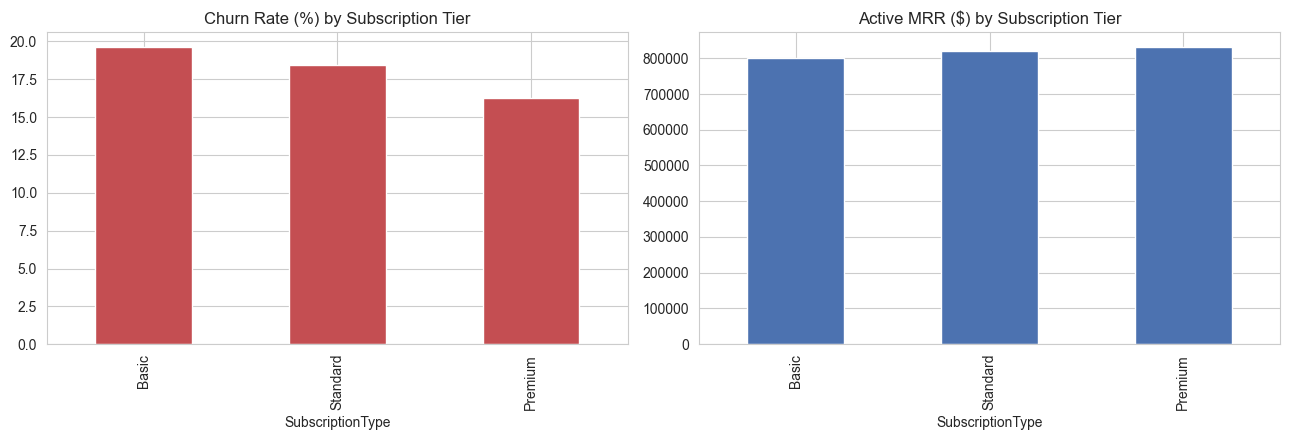

In [7]:
# Business breakdown by plan tier — connects the SaaS metrics to the
# categorical driver identified as most significant in the EDA
# (SubscriptionType, Chi2 = 318.45, the strongest categorical predictor).

tier_summary = train.groupby("SubscriptionType").agg(
    n_customers=("Churn", "count"),
    churn_rate_pct=("Churn", lambda x: x.mean() * 100),
    avg_monthly_charge=("MonthlyCharges", "mean"),
    total_mrr=("MonthlyCharges", lambda x: x[train.loc[x.index, "Churn"] == 0].sum())
).round(2)

tier_summary = tier_summary.reindex(["Basic", "Standard", "Premium"])
print(tier_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tier_summary["churn_rate_pct"].plot(kind="bar", ax=axes[0], color="#C44E52")
axes[0].set_title("Churn Rate (%) by Subscription Tier")

tier_summary["total_mrr"].plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_title("Active MRR ($) by Subscription Tier")

plt.tight_layout()
plt.savefig("../reports/figures/mrr_churn_by_tier.png", dpi=150)
plt.show()

In [8]:
executive_summary = pd.DataFrame({
    "Metric": [
        "MRR", "ARR", "ARPU", "Churn Rate (%)",
        "Revenue Lost from Churn (Monthly)", "CLV (80% margin)",
        "Total Active Customers", "Total Churned Customers"
    ],
    "Value": [
        round(mrr, 2), round(arr, 2), round(arpu, 2), round(churn_rate, 2),
        round(revenue_lost, 2), round(clv, 2),
        int((train["Churn"] == 0).sum()), int((train["Churn"] == 1).sum())
    ]
})

print(executive_summary.to_string(index=False))

# Export for Power BI ingestion (Step 8) and for quoting in the README.
executive_summary.to_csv("../data/processed/executive_summary_metrics.csv", index=False)
train_segmented.to_csv("../data/processed/train_segmented.csv", index=False)

print("\nSaved:")
print("- ../data/processed/executive_summary_metrics.csv")
print("- ../data/processed/train_segmented.csv")

                           Metric       Value
                              MRR  2452372.70
                              ARR 29428472.36
                             ARPU       12.29
                   Churn Rate (%)       18.12
Revenue Lost from Churn (Monthly)   592696.24
                 CLV (80% margin)       54.23
           Total Active Customers   199605.00
          Total Churned Customers    44182.00

Saved:
- ../data/processed/executive_summary_metrics.csv
- ../data/processed/train_segmented.csv
